Implement a character-level LSTM that predicts the next character given a sequence of characters.
Example: Input "mach" → predict "i".

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# -----------------------------------
# 1. Training text
# -----------------------------------
text = "machine learning is amazing"

# Create vocabulary
chars = sorted(list(set(text)))

char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}

vocab_size = len(chars)

print("Vocabulary:", chars)
print("Vocabulary size:", vocab_size)

# -----------------------------------
# 2. Create input-output sequences
# -----------------------------------
seq_length = 5

X = []
y = []

for i in range(len(text) - seq_length):
    sequence = text[i:i + seq_length]
    target = text[i + seq_length]

    X.append([char_to_int[c] for c in sequence])
    y.append(char_to_int[target])

X = np.array(X)
y = np.array(y)

# One-hot encode input and output
X = to_categorical(X, num_classes=vocab_size)
y = to_categorical(y, num_classes=vocab_size)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

# -----------------------------------
# 3. Build LSTM model
# -----------------------------------
model = Sequential([
    LSTM(128, input_shape=(seq_length, vocab_size)),
    Dense(vocab_size, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------------
# 4. Train the model
# -----------------------------------
model.fit(
    X,
    y,
    epochs=100,
    batch_size=16,
    verbose=1
)

# -----------------------------------
# 5. Predict next character
# -----------------------------------
def predict_next_char(sequence):
    # Convert characters to integers
    encoded = [char_to_int[c] for c in sequence]

    # One-hot encode
    encoded = to_categorical(
        encoded,
        num_classes=vocab_size
    )

    # Add batch dimension
    encoded = np.expand_dims(encoded, axis=0)

    # Prediction
    prediction = model.predict(encoded, verbose=0)

    # Get character with highest probability
    predicted_index = np.argmax(prediction)

    return int_to_char[predicted_index]


# -----------------------------------
# 6. Test
# -----------------------------------
input_sequence = "learn"

predicted_char = predict_next_char(input_sequence)

print("\nInput:", input_sequence)
print("Predicted next character:", predicted_char)

Vocabulary: [' ', 'a', 'c', 'e', 'g', 'h', 'i', 'l', 'm', 'n', 'r', 's', 'z']
Vocabulary size: 13
Input shape: (22, 5, 13)
Output shape: (22, 13)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 128)            │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,381 (290.55 KB)

 Trainable params: 74,381 (290.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.0455 - loss: 2.5715
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0909 - loss: 2.5528 
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1364 - loss: 2.5354
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1818 - loss: 2.5199
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2727 - loss: 2.5035
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3182 - loss: 2.4872
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3182 - loss: 2.4700
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3636 - loss: 2.4526
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4091 - loss: 2.4337
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3636 - loss: 2.4127
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3636 - loss: 2.3926 
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3636 - 

**Time-Series Prediction**

Implement LSTM to predict temperature values from a given time-series dataset.
Normalize the data, create input sequences, train the LSTM, and plot actual vs predicted values.

Dataset shape: (420551, 15)
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0    

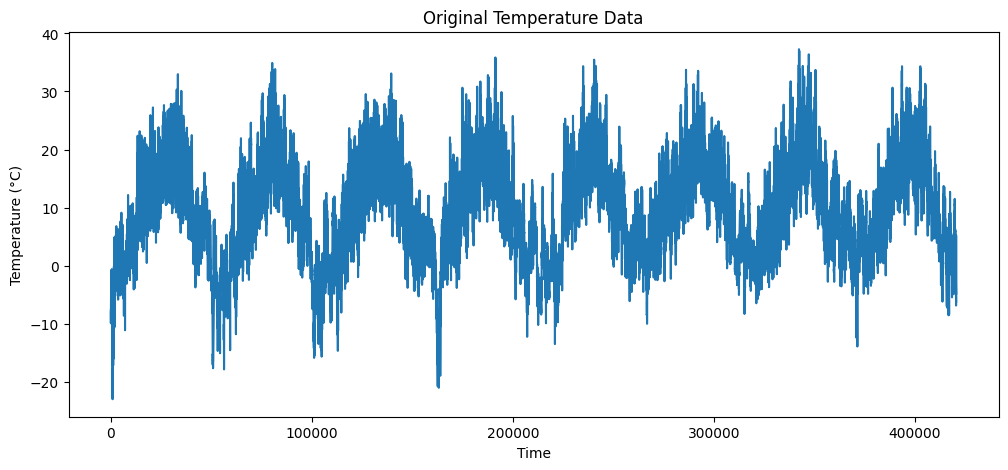


X shape: (420521, 30, 1)
y shape: (420521, 1)

Training samples: 336416
Testing samples: 84105


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 185s 35ms/step - loss: 3.0170e-04 - val_loss: 3.0625e-05
Epoch 2/30
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 191s 36ms/step - loss: 2.4134e-05 - val_loss: 1.2429e-05
Epoch 3/30
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 201s 36ms/step - loss: 1.5392e-05 - val_loss: 1.3390e-05
Epoch 4/30
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 185s 35ms/step - loss: 1.4319e-05 - val_loss: 2.0560e-05
Epoch 5/30
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 201s 35ms/step - loss: 1.3759e-05 - val_loss: 1.1732e-05
Epoch 6/30
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 200s 35ms/step - loss: 1.3366e-05 - val_loss: 1.2337e-05
Epoch 7/30
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 194s 37ms/step - loss: 1.3154e-05 - val_loss: 1.2213e-05
Epoch 8/30
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 185s 35ms/step - loss: 1.2904e-05 - val_loss: 1.1717e-05
Epoch 9/30
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 206s 36ms/step - loss: 1.2928e-05 - val_loss: 1.2768e-05
Epoch 10/30
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 187s 36ms/step - loss: 1.2790e-05 - val_loss: 1.2007e-05
Epoch 11/

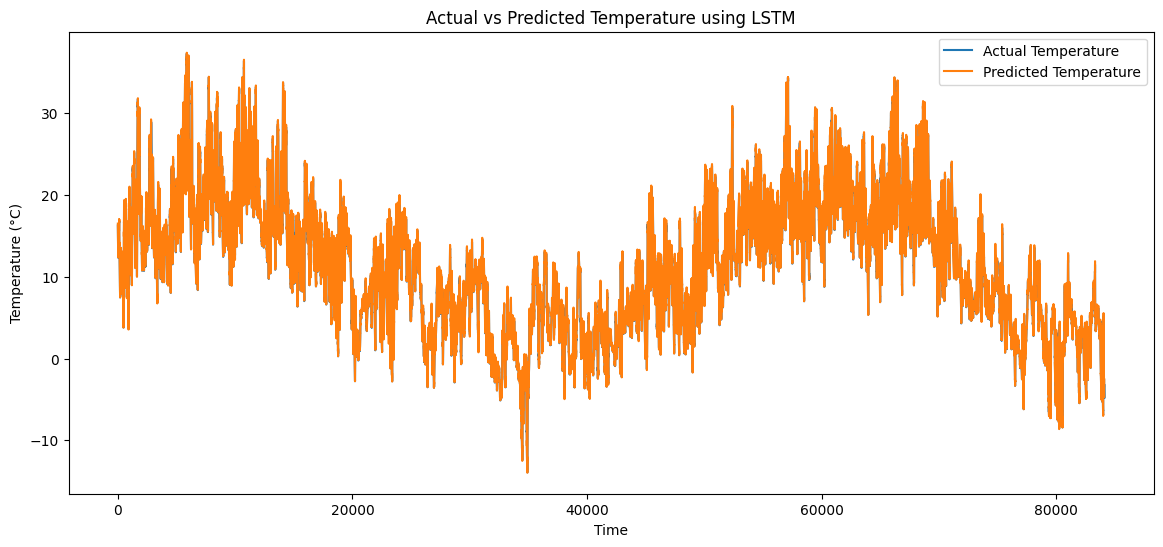

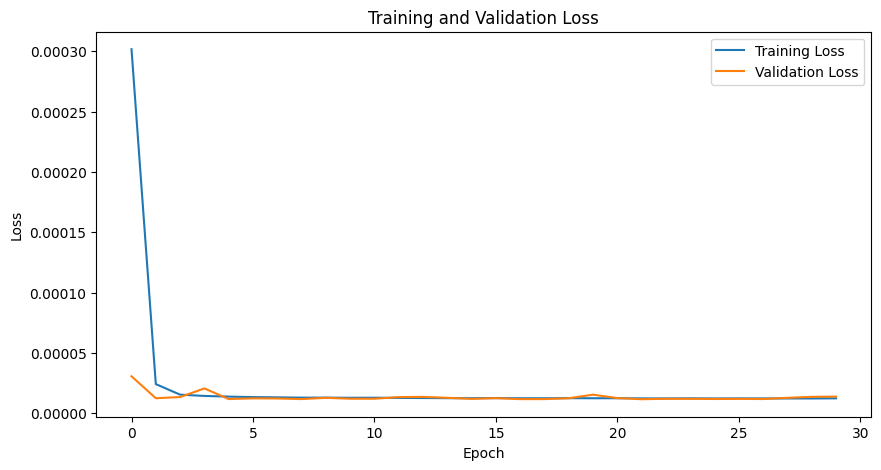

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from zipfile import ZipFile
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


# ============================================
# 1. Download Real Jena Climate Dataset
# ============================================

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin=url
)

with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("jena_climate_2009_2016.csv")

print("Dataset shape:", df.shape)
print(df.head())


# ============================================
# 2. Select Temperature
# ============================================

temperature = df["T (degC)"].values

print("\nNumber of records:", len(temperature))


# ============================================
# 3. Plot Original Temperature
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(temperature)

plt.title("Original Temperature Data")

plt.xlabel("Time")

plt.ylabel("Temperature (°C)")

plt.show()


# ============================================
# 4. Normalize Data
# ============================================

scaler = MinMaxScaler(feature_range=(0, 1))

temperature_scaled = scaler.fit_transform(
    temperature.reshape(-1, 1)
)


# ============================================
# 5. Create Sequences
# ============================================

sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(temperature_scaled)):

    X.append(
        temperature_scaled[i-sequence_length:i]
    )

    y.append(
        temperature_scaled[i]
    )

X = np.array(X)
y = np.array(y)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# ============================================
# 6. Train-Test Split
# ============================================

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================
# 7. Build LSTM
# ============================================

model = Sequential([
    LSTM(
        50,
        return_sequences=True,
        input_shape=(sequence_length, 1)
    ),

    LSTM(50),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()


# ============================================
# 8. Train Model
# ============================================

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)


# ============================================
# 9. Predict
# ============================================

predicted = model.predict(X_test)


# ============================================
# 10. Convert Back to Celsius
# ============================================

predicted_temperature = scaler.inverse_transform(
    predicted
)

actual_temperature = scaler.inverse_transform(
    y_test
)


# ============================================
# 11. Evaluation
# ============================================

mae = mean_absolute_error(
    actual_temperature,
    predicted_temperature
)

rmse = np.sqrt(
    mean_squared_error(
        actual_temperature,
        predicted_temperature
    )
)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("MAE :", mae)
print("RMSE:", rmse)


# ============================================
# 12. Actual vs Predicted
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    actual_temperature,
    label="Actual Temperature"
)

plt.plot(
    predicted_temperature,
    label="Predicted Temperature"
)

plt.title(
    "Actual vs Predicted Temperature using LSTM"
)

plt.xlabel("Time")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.show()


# ============================================
# 13. Training Loss
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()